In [1]:
!pip install opendatasets

In [2]:
!pip install patchify

In [3]:
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Navodit Sahai
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery


100%|██████████| 29.6M/29.6M [00:00<00:00, 42.3MB/s]


In [4]:
#KGAT_d5bf7c248b6df8772cef8fd2ec16a59b

In [5]:
root_folder="/content/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset"

In [6]:
import os
import cv2
from PIL import Image
import numpy as np
from patchify import patchify
from sklearn.preprocessing import MinMaxScaler

In [7]:
#/content/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset/Tile 1/images/image_part_001.jpg

In [8]:
#/content/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset/Tile 1/masks/image_part_001.png

In [9]:
patch_size=256

In [10]:

min_max_scaler=MinMaxScaler()

In [11]:
image_dataset=[]
mask_dataset=[]

for image_type in ['images','masks']:
  if image_type=='images':
    image_extension='jpg'
  else:
    image_extension='png'
  for tile_id in range(1,8):
    for image_id in range(1,20):
      image=cv2.imread(f'{root_folder}/Tile {tile_id}/{image_type}/image_part_00{image_id}.{image_extension}')
      if image is not None:
        if image_type=="masks":
          image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        size_x=(image.shape[1]//patch_size)*patch_size
        size_y=(image.shape[0]//patch_size)*patch_size
        image=Image.fromarray(image)
        image=image.crop((0,0,size_x,size_y))
        image=np.array(image)
        img_patches=patchify(image,(patch_size,patch_size,3),step=patch_size)
        #print(img_patches.shape) e.g (2, 3, 1, 256, 256, 3)
        #(2 patches_in_height, 3 patches_in_width, 1 patch_in_channel_dimension(3/3),256,256,3)
        for i in range(img_patches.shape[0]):
          for j in range(img_patches.shape[1]):
            if image_type=='images':
              individual_patched_image=img_patches[i,j,:,:,:]
              #flattening the image keeping the channels same (H*W, 3)
              flattened_patched_image= individual_patched_image.reshape(-1,individual_patched_image.shape[-1])
              #applying min-max scaler
              scaled_patched_image=min_max_scaler.fit_transform(flattened_patched_image)
              #reshaping it into original dimension
              reshaped_patched_image=scaled_patched_image.reshape(individual_patched_image.shape)
              individual_patched_image = reshaped_patched_image[0].astype('float16')
              image_dataset.append(individual_patched_image)
            else:
              individual_patched_mask=img_patches[i,j,:,:,:]
              individual_patched_mask = individual_patched_mask[0].astype('uint8')
              mask_dataset.append(individual_patched_mask)

In [12]:
len(image_dataset)

945

In [13]:
len(mask_dataset)

945

In [14]:
image_dataset = np.array(image_dataset, dtype=np.float16)
mask_dataset = np.array(mask_dataset, dtype=np.uint8)

In [15]:
image_dataset=np.array(image_dataset)
mask_dataset=np.array(mask_dataset)

In [16]:
from matplotlib import pyplot as plt

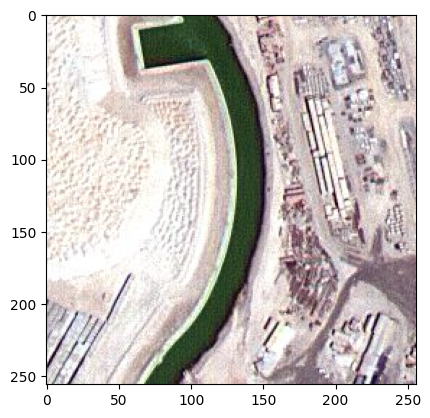

In [17]:
plt.imshow(image_dataset[0].astype('float32'))

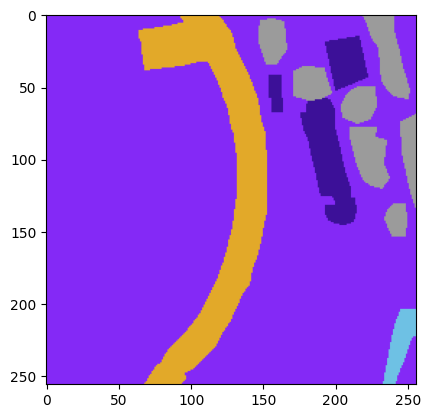

In [18]:
plt.imshow(mask_dataset[0])

In [19]:
import numpy as np
# Water
class_water='#E2A929'
class_water=class_water.lstrip('#')
class_water=np.array(tuple(int(class_water[i:i+2],16) for i in (0,2,4)))
print(class_water)


# Building
class_building = '#3C1098'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0, 2, 4)))
print(class_building)

# Land
class_land = '#8429F6'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0, 2, 4)))
print(class_land)

# Road
class_road = '#6EC1E4'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0, 2, 4)))
print(class_road)

# Vegetation
class_vegetation = '#FEDD3A'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0, 2, 4)))
print(class_vegetation)

# Unlabeled
class_unlabeled = '#9B9B9B'
class_unlabeled = class_unlabeled.lstrip('#')
class_unlabeled = np.array(tuple(int(class_unlabeled[i:i+2], 16) for i in (0, 2, 4)))
print(class_unlabeled)

[226 169  41]
[ 60  16 152]
[132  41 246]
[110 193 228]
[254 221  58]
[155 155 155]


In [20]:
def rgb_label(label):
  label_segment=np.zeros(label.shape,dtype=np.uint8)
  label_segment[np.all(label==class_water,axis=-1)]=0
  label_segment[np.all(label==class_land,axis=-1)]=1
  label_segment[np.all(label==class_road,axis=-1)]=2
  label_segment[np.all(label==class_building,axis=-1)]=3
  label_segment[np.all(label==class_vegetation,axis=-1)]=4
  label_segment[np.all(label==class_unlabeled,axis=-1)]=5
  label_segment=label_segment[:,:,0]
  return label_segment


In [21]:
labels=[]
for i in range(mask_dataset.shape[0]):
  label=rgb_label(mask_dataset[i])
  labels.append(label)

In [22]:
labels=np.array(labels)
labels=np.expand_dims(labels,axis=3)

In [23]:
master_training_dataset=image_dataset

In [24]:
from tensorflow.keras.utils import to_categorical
label_categorical_dataset = to_categorical(labels, num_classes=6).astype('float16')

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(master_training_dataset,label_categorical_dataset,test_size=0.15,random_state=100)


MODEL TRAINING AND EVALUATION

In [26]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D,UpSampling2D,Conv2DTranspose
from keras.layers import concatenate, BatchNormalization,Dropout,Lambda
from keras import backend as k #for keras backend operations(tensor level) (by default keras backend is tensorflow only)

In [27]:
#jeccard index is IOU(Intersection Over Union)
def jeccard_coef(y_true,y_pred):
  # Explicitly cast both y_true and y_pred to float16 to ensure type consistency
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred>0.5, tf.float32)

  y_true_flatten=tf.keras.backend.flatten(y_true)
  y_pred_flatten=tf.keras.backend.flatten(y_pred)
  intersection=tf.keras.backend.sum(y_true_flatten*y_pred_flatten)
  union=tf.keras.backend.sum(y_true_flatten)+tf.keras.backend.sum(y_pred_flatten)-intersection
  # Ensure constants are also float32 to match tensor types
  return (intersection+tf.cast(1e-7, tf.float32))/(union+tf.cast(1e-7, tf.float32))

In [28]:
def multi_unet_model(n_classes=6, image_height=128, image_width=128, image_channels=3):

    inputs = Input((image_height, image_width, image_channels))

    c1 = Conv2D(8, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(8, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2,2))(c4)

    c5 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    u6 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(16, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(8, (2,2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(8, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(8, (3,3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(n_classes, (1,1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

In [29]:
metrics=["accuracy",jeccard_coef]

In [30]:
def get_model():
  return multi_unet_model(n_classes=y_train.shape[3],image_height=256,image_width=256,image_channels=3)

In [31]:
model=get_model()

GENERATION LOSS FUNCTIONS

In [32]:
weights=[0.166,0.166,0.166,0.166,0.166,0.166]

In [33]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

# Remove explicit old TF/Keras installs that cause conflicts
# !pip install tensorflow==2.10 # This version is not found
# !pip install keras==2.10 # This causes API conflicts with newer TF
# Reinstall segmentation_models to ensure it uses compatible versions
!pip install -U segmentation-models
import segmentation_models as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.9 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.


In [34]:
dice_loss=sm.losses.DiceLoss(class_weights=weights)
focal_loss=sm.losses.CategoricalFocalLoss()
total_loss=dice_loss+(1*focal_loss)


In [35]:
import tensorflow as tf
tf.keras.backend.clear_session()
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [36]:
model.compile(optimizer="adam",loss=total_loss,metrics=metrics)

In [38]:
model_history=model.fit(x_train,y_train,batch_size=8,verbose=1,epochs=10,validation_data=(x_test,y_test),shuffle=False)

Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.6979 - jeccard_coef: 0.5396 - loss: 0.9718 - val_accuracy: 0.6140 - val_jeccard_coef: 0.4461 - val_loss: 0.9975
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.7221 - jeccard_coef: 0.5676 - loss: 0.9653 - val_accuracy: 0.6698 - val_jeccard_coef: 0.5130 - val_loss: 0.9747
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.7436 - jeccard_coef: 0.6015 - loss: 0.9578 - val_accuracy: 0.7330 - val_jeccard_coef: 0.5814 - val_loss: 0.9588
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 316s 3s/step - accuracy: 0.7523 - jeccard_coef: 0.6150 - loss: 0.9548 - val_accuracy: 0.7310 - val_jeccard_coef: 0.5787 - val_loss: 0.9608
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.7602 - jeccard_coef: 0.6264 - loss: 0.9519 - val_accuracy: 0.7460 - val_jeccard_coef: 0.5985 - val_loss: 0.9583
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - accuracy: 0.7625 - jeccard_coef: 0.6287 - loss: 0.

In [39]:
model.save("my_model.h5")